[Material used to generate Fig.2]

Infiltrability (zero stage seepage) curves of different clogged streambeds (of equal shape parameter) are computed as function of the clogging thickness. The curves are shown to collapse under relevant rescaling. Both van Genuchten-Mualem and Brooks-Corey-Burdine models are considered.

In [14]:
# Standard imports
import sys
from pathlib import Path

# Third party imports
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as colors

# Internal imports
sys.path.append('..')
from rate import q_exact_full

In [15]:
# set plot style
%matplotlib widget
plt.style.use('plot_style.txt')

# output path for figures 
output_path = Path("/home/jonas/shared/Work/SSeep2026/Figures")

Compute infiltrability curves of five different configurations

In [16]:
# clogging layer
cl_th = np.logspace(-5, 4, 200)
cl_cond = [1e-5, 1e-7, 3e-4, 2e-7, 3e-6]

# aquifer 
aq_cond = [1e-4, 3e-3, 1e-3, 1e-5, 7e-4]
aq_scale = [0.1, 0.3, 0.5, 0.05, 1]
b = 3.25 # generalized shape parameters
aq_shape_vGM = (2 * b + 1) / 5 # convert to vGM
aq_shape_BCB = (b - 2) / 3 # convert to BCB


# compute seepage
q_vGM = dict()
q_BCB = dict()
for i in range(5):
    q_vGM[i] = np.array([q_exact_full(0, cl_cond[i], x, aq_cond[i], aq_scale[i],
                                      aq_shape_vGM, aq_para='vGM')
                                      for x in cl_th])
    
    q_BCB[i] = np.array([q_exact_full(0, cl_cond[i], x, aq_cond[i], aq_scale[i],
                                      aq_shape_BCB, aq_para='BCB')
                                      for x in cl_th])

Plot seepage rate against clogging thickness

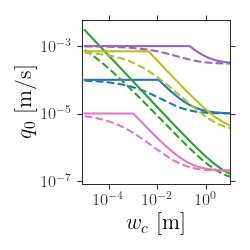

In [17]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(top=True, right=True)
ax.set(xscale='log', yscale='log')


# set colors
cmap = cm.tab10
norm = colors.Normalize(vmin=0, vmax=5)


# plot infiltrability curves
for i in range(5):
    c = cmap(norm(i))
    ax.plot(cl_th, q_vGM[i], c=c, ls='--', lw=1.5)
    ax.plot(cl_th, q_BCB[i], c=c, ls='-', lw=1.5)


# layout
ax.set_xlim(xmin=0.8e-5, xmax=1e1)
ax.set_ylim(ymin=8e-8, ymax=.6e-2)
ax.set_xticks([1e-4, 1e-2, 1e0])
ax.set_yticks([1e-7, 1e-5, 1e-3])
ax.set_xlabel("$w_c$ [m]", fontsize=16)
ax.set_ylabel("$q_0$ [m/s]", fontsize=16)
ax.minorticks_off()

plt.tight_layout()
#plt.savefig(output_path / "curve-collapse-before.pdf")

Plot normalized infiltrability ($q_0 / K_a$) against the dimensionless ratio $x = B^{-1/b} w_c K_a / h_g K_c$

In [18]:
def log_log_triangle(x1, x2, y1, y2=None, slope=None):
    """
    Draw a triangle in a log-log plot.

    Parameters:
    -----------
    x1: float
        x coordinate of the base/diagonal vertex.
    x2: float
        x coordinate of the top vertex.
    y1: float
        y coordinate of the base.
    y2: float, optional
        y coordinate of the top vertex. If none computed fromt eh slope. Default
        is None.
    slope: float, optional
        Diagonal slope. If None, y2 must be specified. Default is None.
    """

    if y2 is None and slope is None:
        raise ValueError("Either y2 or slope must be specified")

    if y2 is None:
        y2 = y1 * (x2 / x1) ** slope

    plt.plot([x1, x2, x2, x1], [y1, y2, y1, y1], "k-")

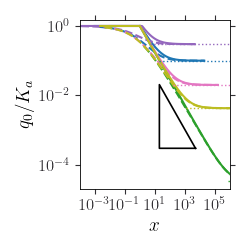

In [19]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(top=True, right=True)
ax.set(xscale='log', yscale='log')
ax.minorticks_off()


# set colors
cmap = cm.tab10
norm = colors.Normalize(vmin=0, vmax=5) 



# rescale and plot infiltrability
xmin, xmax = 1e-4, 1e6
for i in range(5):
    c = cmap(norm(i))

    # rescale 
    B_vGM = (1 - 1 / aq_shape_vGM)**2
    B_BCB = 1
    x_sh = (aq_cond[i] / cl_cond[i])**(1+1/b)
    x_vGM = B_vGM**(-1/b) * cl_th * aq_cond[i] / (aq_scale[i] * cl_cond[i])
    x_BCB = B_BCB**(-1/b) * cl_th * aq_cond[i] / (aq_scale[i] * cl_cond[i])

    # plot
    ax.plot(x_vGM[x_vGM<1e3*x_sh], q_vGM[i][x_vGM<1e3*x_sh] / aq_cond[i],
            c=c, ls='--', lw=1.5, zorder=0)
    
    ax.plot(x_BCB[x_BCB<1e3*x_sh], q_BCB[i][x_BCB<1e3*x_sh] / aq_cond[i],
            c=c, ls='-', lw=1.5, zorder=0)
    
    # plot hard clogging limit
    ax.axhline(cl_cond[i] / aq_cond[i],
               xmin=np.log10(x_sh/xmin) / np.log10(xmax/xmin),
               color=c, lw=1, ls=':')


# plot predicted slope
log_log_triangle(5e3, 2e1, 3e-4, slope=-(b/(1+b)))



# layout
ax.set_xlabel("$x$", fontsize=14)
ax.set_ylabel("$q_0 / K_a$", fontsize=14)
ax.set_xlim(xmin, xmax)
ax.set_xticks([1e-3, 1e-1, 1e1, 1e3, 1e5])
ax.set_yticks([1e-4, 1e-2, 1e0])
ax.set_ylim(ymin=2e-5, ymax=1.5e0)

plt.tight_layout()
#plt.savefig(output_path / "curve-collapse-after.pdf")